# Final Project:
 ##### Author: Evan Williams
 ##### CSE432: Machine Learning

## Project Overview
The **Final Project** builds on the work from the midterm project to design, implement, and evaluate machine learning models. The primary goal is to classify user activities based on accelerometer and gyroscope data using a variety of machine learning algorithms, hyperparameter tuning, and evaluation techniques. 

---

## Objectives
1. **Feature Extraction**:
   - Extract meaningful statistical features from accelerometer and gyroscope data for model training.

2. **Model Implementation**:
   - Train and evaluate a variety of machine learning models:
     - Logistic Regression
     - Decision Trees
     - Random Forest
     - Gradient Boosting
     - XGBoost
     - Support Vector Machines (SVM)
     - K-Nearest Neighbors (KNN)
     - AdaBoost
     - Artificial Neural Networks (ANN)

3. **Hyperparameter Optimization**:
   - Use **Grid Search** and **Randomized Search** to optimize hyperparameters for each model.

4. **Cross-Validation Techniques**:
   - Employ K-Fold and Stratified K-Fold cross-validation for model robustness.

5. **Model Evaluation**:
   - Evaluate models using validation and test datasets, with metrics such as:
     - Accuracy
     - Precision
     - Recall
     - F1 Score
     - AUC (Area Under the Curve)

## Importing from Midterm Project

We are importing components and utilizing data preparation steps from the **Midterm Project**. This ensures continuity and reusability of code for feature extraction and processing while transitioning to the final project. Below are the steps followed:

User folders detected: ['User2', 'User5', 'User4', 'User3', 'User12', 'User8', 'User6', 'User1', 'User7', 'User9', 'User10', 'User11']
User folders detected: ['User2', 'User5', 'User4', 'User3', 'User12', 'User8', 'User6', 'User1', 'User7', 'User9', 'User10', 'User11']
All data keys: dict_keys([])


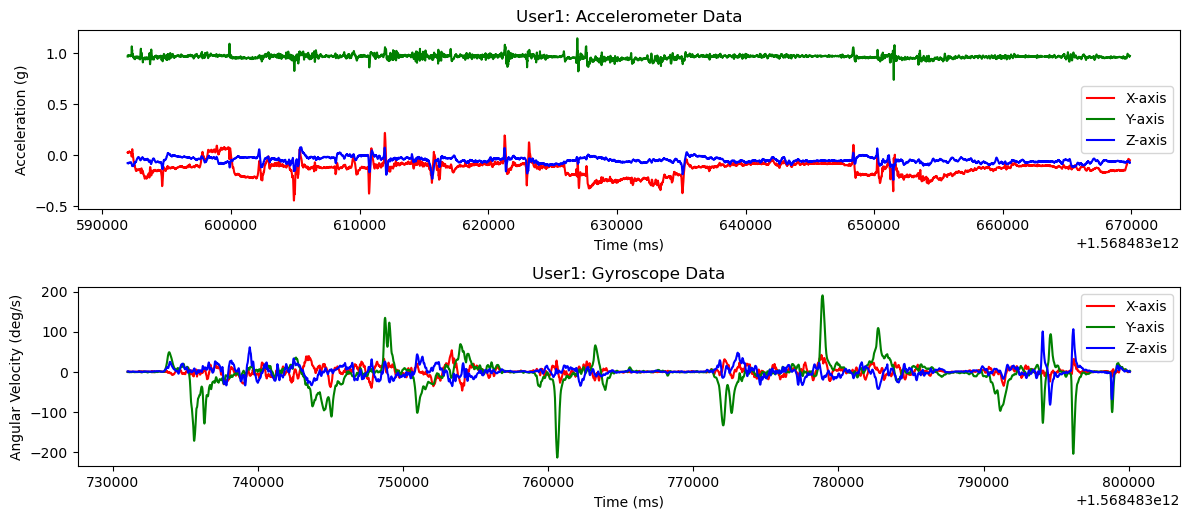

Created 39 windows for accelerometer and 39 windows for gyroscope.
Extracted features for 39 windows for user User1.
First 10 rows of the extracted features:
   acc_x_mean  acc_y_mean  acc_z_mean  acc_x_std  acc_y_std  acc_z_std  \
0   -0.122825    0.962110   -0.056775   0.085340   0.025754   0.023135   
1   -0.142800    0.963600   -0.035360   0.032162   0.015126   0.036045   
2   -0.097785    0.970445   -0.028205   0.036984   0.009740   0.010852   
3    0.039395    0.978645   -0.055260   0.033689   0.017265   0.027086   
4   -0.189155    0.952605   -0.026570   0.052022   0.005811   0.010472   
5   -0.115495    0.967660   -0.041060   0.052737   0.014894   0.031192   
6   -0.131260    0.964445   -0.042900   0.088310   0.028188   0.055807   
7   -0.121700    0.968915   -0.025430   0.010513   0.014790   0.007032   
8   -0.118250    0.969980   -0.011035   0.035408   0.016604   0.022102   
9   -0.104700    0.971565   -0.016670   0.077560   0.020652   0.039874   

   gyro_x_mean  gyro_y_mean

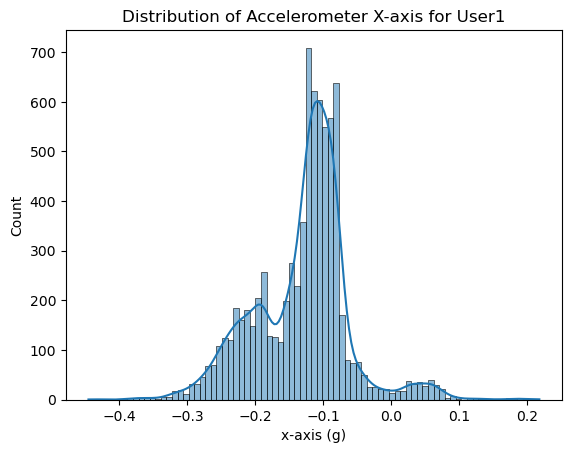

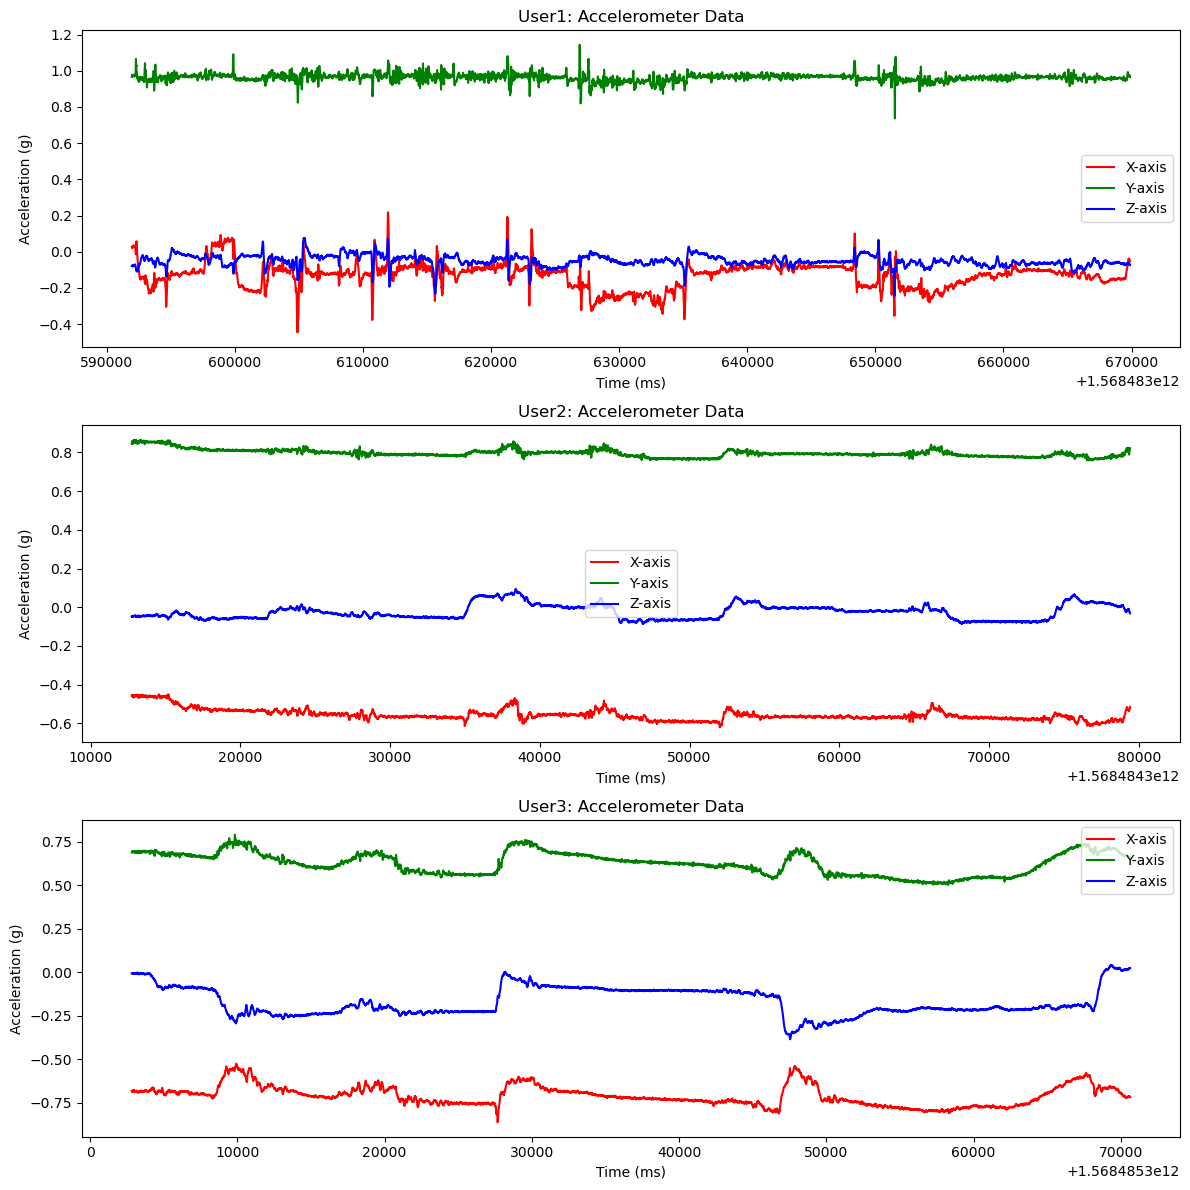

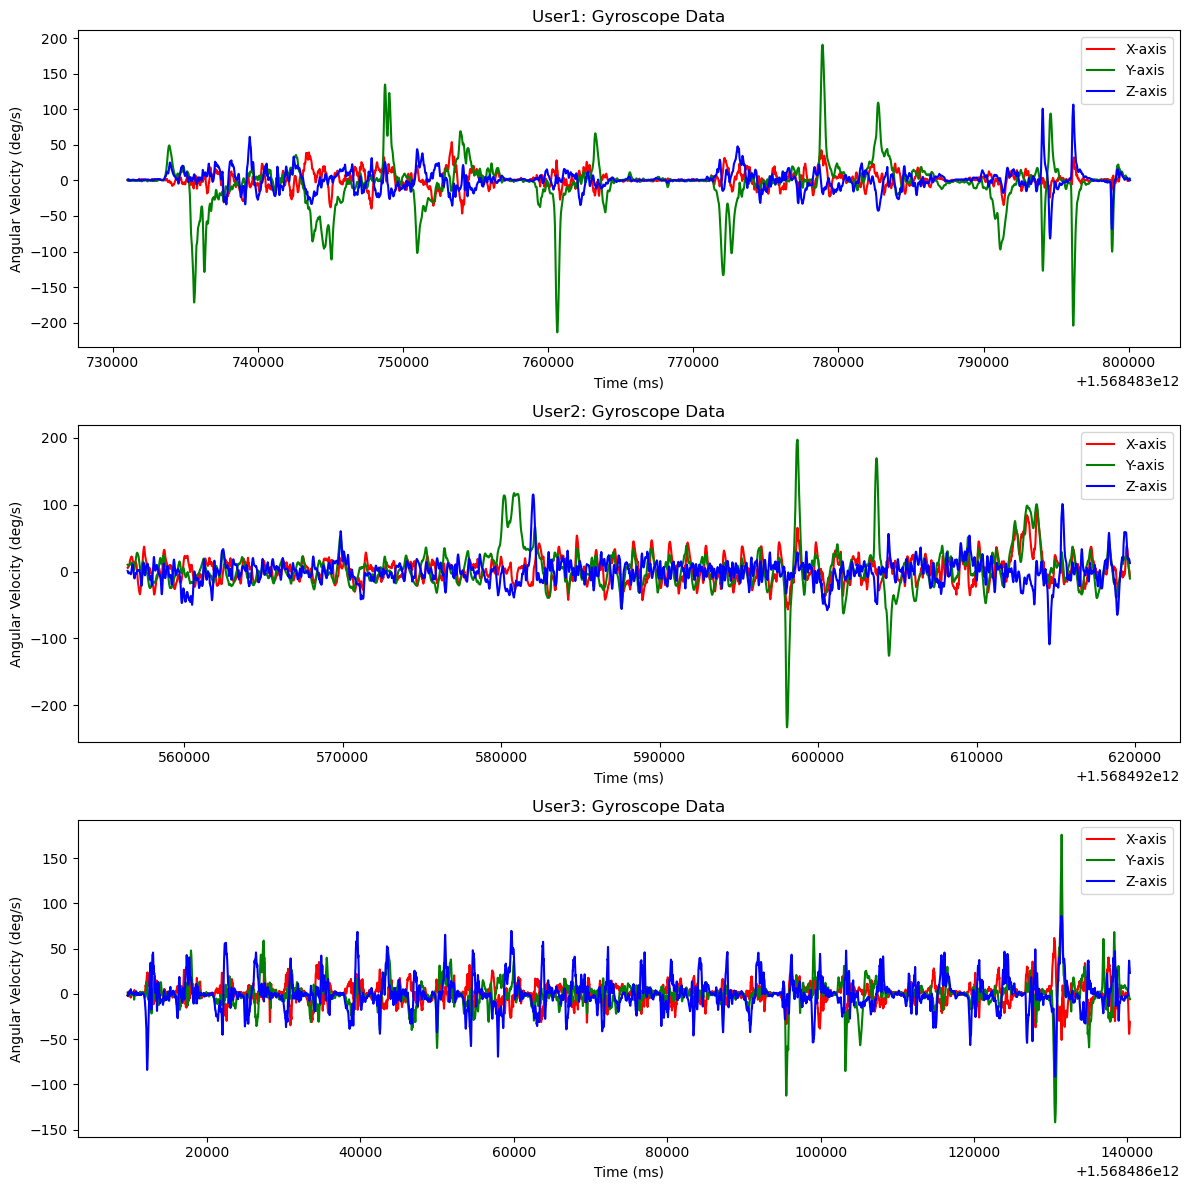

In [440]:
import os
import pandas as pd

base_dir = '/Users/mikeyarias/Desktop/CSE432-Machine Learning/Final_ClassProject/DataSet1/'

if not os.path.exists(base_dir):
    print(f"Directory does not exist: {base_dir}")
else:
    # List user folders
    user_folders = [f for f in os.listdir(base_dir) if f.startswith('User')]
    print("User folders detected:", user_folders)

# Running the midterm_classProject notebook
%run midterm_classProject.ipynb

# Data Preprocessing and Feature Extraction

## Overview
This section handles the preprocessing of raw accelerometer and gyroscope data to prepare it for machine learning models. The workflow includes cleaning the data, creating sliding windows for time-series segmentation, and extracting statistical features from each window.

---

## Steps

### 1. **Data Cleaning**
`clean_data` function:
- Removes missing values (`NaN`), Eliminates duplicate rows, Resets the index for consistency.

### 2. **Window Creation**
`create_windows` function:
- Segments accelerometer and gyroscope data into overlapping time windows.
- Outputs separate lists of windows for accelerometer and gyroscope data.

### 3. **Feature Extraction**
The `extract_features` function:
- Computes statistical features
- Outputs a DataFrame of extracted features.


In [90]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def clean_data(df):
    df_cleaned = df.dropna()
    df_cleaned = df_cleaned.drop_duplicates()
    df_cleaned = df_cleaned.reset_index(drop=True)
    return df_cleaned
    
def create_windows(user_data, window_size, overlap=0.0):
    acc_windows = []
    gyro_windows = []

    acc_data = user_data.get('accelerometer')
    gyro_data = user_data.get('gyroscope')

    if acc_data is None or gyro_data is None:
        print("Missing data for accelerometer or gyroscope.")
        return acc_windows, gyro_windows

    data_length = len(acc_data)
    step = int(window_size * (1 - overlap))

    for start in range(0, data_length, step):
        end = start + window_size
        if end > data_length:
            break
        
        acc_window = acc_data.iloc[start:end]
        gyro_window = gyro_data.iloc[start:end]

        acc_windows.append(acc_window)
        gyro_windows.append(gyro_window)

    print(f"Created {len(acc_windows)} windows for accelerometer and {len(gyro_windows)} windows for gyroscope with window size {window_size} and {int(overlap*100)}% overlap.")
    return acc_windows, gyro_windows

def extract_features(acc_windows, gyro_windows, user, label):
    features = []
    for acc_window, gyro_window in zip(acc_windows, gyro_windows):
        feature_dict = {}

        # Accelerometer features
        feature_dict['acc_x_mean'] = acc_window['x-axis (g)'].mean()
        feature_dict['acc_y_mean'] = acc_window['y-axis (g)'].mean()
        feature_dict['acc_z_mean'] = acc_window['z-axis (g)'].mean()
        feature_dict['acc_x_std']  = acc_window['x-axis (g)'].std()
        feature_dict['acc_y_std']  = acc_window['y-axis (g)'].std()
        feature_dict['acc_z_std']  = acc_window['z-axis (g)'].std()

        # Gyroscope features
        feature_dict['gyro_x_mean'] = gyro_window['x-axis (deg/s)'].mean()
        feature_dict['gyro_y_mean'] = gyro_window['y-axis (deg/s)'].mean()
        feature_dict['gyro_z_mean'] = gyro_window['z-axis (deg/s)'].mean()
        feature_dict['gyro_x_std']  = gyro_window['x-axis (deg/s)'].std()
        feature_dict['gyro_y_std']  = gyro_window['y-axis (deg/s)'].std()
        feature_dict['gyro_z_std']  = gyro_window['z-axis (deg/s)'].std()

        # Add user_id and label
        feature_dict['user_id'] = user
        feature_dict['label'] = label

        features.append(feature_dict)

    features_df = pd.DataFrame(features)
    print(f"Extracted features for {len(features_df)} windows for user {user} with label {label}.")
    return features_df

for W in window_sizes:
    for O in overlaps:
        # Create windows with the specified parameters
        acc_win, gyro_win = create_windows(user_data, W, O)

        # Extract features including user_id and label
        features_df = extract_features(acc_win, gyro_win, user='User1', label='walking')

        # Construct the filename based on W and O
        O_percentage = int(O * 100)
        filename = f"W{W}_O{O_percentage}_Features.csv"
        output_path = os.path.join(output_dir, filename)

        # Save to CSV
        features_df.to_csv(output_path, index=False)
        print(f"Saved features to {output_path}")

Created 103 windows for accelerometer and 103 windows for gyroscope with window size 100 and 25% overlap.
Extracted features for 103 windows for user User1 with label walking.
Saved features to /Users/mikeyarias/Desktop/CSE432-Machine Learning/Final_ClassProject/W100_O25_Features.csv
Created 154 windows for accelerometer and 154 windows for gyroscope with window size 100 and 50% overlap.
Extracted features for 154 windows for user User1 with label walking.
Saved features to /Users/mikeyarias/Desktop/CSE432-Machine Learning/Final_ClassProject/W100_O50_Features.csv
Created 51 windows for accelerometer and 51 windows for gyroscope with window size 200 and 25% overlap.
Extracted features for 51 windows for user User1 with label walking.
Saved features to /Users/mikeyarias/Desktop/CSE432-Machine Learning/Final_ClassProject/W200_O25_Features.csv
Created 76 windows for accelerometer and 76 windows for gyroscope with window size 200 and 50% overlap.
Extracted features for 76 windows for user U

# Loading Feature Data

## Overview
This section loads the extracted feature data from a pre-generated CSV file for further processing and analysis.


In [92]:
import pandas as pd
import numpy as np

# Path
features_file = "/Users/mikeyarias/Desktop/CSE432-Machine Learning/Final_ClassProject/W100_O25_Features.csv"
features_df = pd.read_csv(features_file)

# Check the first few rows
print(features_df.head())

   acc_x_mean  acc_y_mean  acc_z_mean  acc_x_std  acc_y_std  acc_z_std  \
0    -0.06160     0.96723    -0.06629   0.078398   0.021591   0.025879   
1    -0.17890     0.95397    -0.03922   0.032940   0.021398   0.011000   
2    -0.16525     0.95810    -0.05798   0.024587   0.023405   0.013646   
3    -0.15402     0.95931    -0.05219   0.040878   0.015930   0.039278   
4    -0.12467     0.96862    -0.00421   0.005891   0.014062   0.010126   

   gyro_x_mean  gyro_y_mean  gyro_z_mean  gyro_x_std  gyro_y_std  gyro_z_std  \
0      0.31714     -0.45075      0.44158    0.521269    0.421192    0.444168   
1      0.63550     -0.31039      0.55142    0.582631    0.574484    0.425062   
2      0.57748      0.04328      0.98717    0.637275    0.630557    0.586621   
3     -1.56582     18.96228      9.06771    2.864180   17.499014    7.584519   
4     -1.65252     12.94817      8.84634    3.796382    7.418146    6.974416   

  user_id    label  
0   User1  walking  
1   User1  walking  
2   User1  

# Machine Learning Model Setup

## Overview
This section establishes the foundation for training and evaluating various machine learning models. It includes essential imports, model definitions, evaluation metrics, and hyperparameter search utilities.

---

## Key Components

### 1. **Model Imports**
- Includes popular machine learning models such as Logistic Regression, Decision Trees, Random Forests, Gradient Boosting, XGBoost, and Neural Networks.

### 2. **Evaluation Functions**
- `evaluate_model`: Computes metrics such as accuracy, precision, recall, F1 score, and AUC for model evaluation.
- `confusion_matrix`: Outputs the confusion matrix for detailed classification performance.

### 3. **Hyperparameter Tuning**
- `run_grid_search`: Performs an exhaustive search for optimal model parameters.
- `run_random_search`: Implements a randomized search for faster hyperparameter tuning.

---

## Purpose
This setup provides a unified and reusable structure for training and evaluating models while optimizing their performance using cross-validation and hyperparameter tuning.

In [96]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier
import warnings
warnings.filterwarnings('ignore')

def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    if y_pred.ndim > 1 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)
    auc = roc_auc_score(y_val, y_pred) if len(np.unique(y_val)) == 2 else "N/A"
    cm = confusion_matrix(y_val, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("AUC:", auc)
    print("Confusion Matrix:\n", cm)
    return acc, prec, rec, f1, auc

def run_grid_search(model, param_grid, X_train, y_train, cv=5, scoring='accuracy'):
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=cv, scoring=scoring, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print("Best Parameters:", grid_search.best_params_)
    return grid_search.best_estimator_

def run_random_search(model, param_dist, X_train, y_train, cv=5, scoring='accuracy', n_iter=10):
    random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, cv=cv, scoring=scoring, n_jobs=-1, n_iter=n_iter, random_state=42)
    random_search.fit(X_train, y_train)
    print("Best Parameters (Random Search):", random_search.best_params_)
    return random_search.best_estimator_

# Data Splitting for Training and Testing

This section prepares the dataset by splitting it into training and test sets based on unique user IDs.


In [302]:
features_file = "/Users/mikeyarias/Desktop/CSE432-Machine Learning/Final_ClassProject/W100_O25_Features.csv"
features_df = pd.read_csv(features_file)

X = features_df.drop(columns=['user_id', 'label'])  # Features
y = features_df['label']  # Target variable

unique_users = features_df['user_id'].unique()
test_user_ratio = 0.2
test_user_count = int(len(unique_users) * test_user_ratio)

test_users = np.random.choice(unique_users, size=test_user_count, replace=False)

test_mask = features_df['user_id'].isin(test_users)
train_mask = ~test_mask

X_train_users = X[train_mask]
y_train_users = y[train_mask]

X_test_users = X[test_mask]
y_test_users = y[test_mask]

## Machine Learning Models Implementation

This section implements the machine learning models listed in the project with hyperparameter tuning and cross-validation to evaluate their performance on the dataset.

1. **Logistic Regression**  

2. **Decision Tree**  

3. **Random Forest**  

4. **Gaussian Naïve Bayes**  

5. **Support Vector Machine (SVM)**  

6. **K-Nearest Neighbors (KNN)**  

7. **AdaBoost**  

8. **Gradient Boosting**  

9. **XGBoost**  

10. **Artificial Neural Network (ANN)**  

Each model's performance is evaluated using validation and test sets, applying metrics like accuracy, precision, recall, F1 score, and AUC.

# Logistic Regression

In [203]:
# Logistic Regression Model and Hyperparameter Grid
lr_model = LogisticRegression(max_iter=1000)
lr_param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2']
}

# Grid Search for Best Parameters
best_lr = run_grid_search(lr_model, lr_param_grid, X_train, y_train, cv=5)

# Validation Set Evaluation
print("\nValidation Set Evaluation:")
evaluate_model(best_lr, X_val, y_val)

# Test Set Evaluation
print("\nTest Set Evaluation (Held-Out Users):")
evaluate_model(best_lr, X_test_users, y_test_users)

Best Parameters: {'C': 10, 'penalty': 'l2'}

Validation Set Evaluation:
Accuracy: 0.5882352941176471
Precision: 0.5865546218487395
Recall: 0.5882352941176471
F1 Score: 0.5853457172342622
AUC: 0.5833333333333334
Confusion Matrix:
 [[6 3]
 [4 4]]

Test Set Evaluation (Held-Out Users):
Accuracy: 0.6666666666666666
Precision: 0.6696969696969697
Recall: 0.6666666666666666
F1 Score: 0.6666666666666666
AUC: 0.6681818181818182
Confusion Matrix:
 [[7 4]
 [3 7]]


(0.6666666666666666,
 0.6696969696969697,
 0.6666666666666666,
 0.6666666666666666,
 0.6681818181818182)

# Decision Trees

In [207]:
# Decision Tree Model and Hyperparameter Grid
dt_model = DecisionTreeClassifier(random_state=42)
dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search for Best Parameters
best_dt = run_grid_search(dt_model, dt_param_grid, X_train, y_train, cv=5)

# Validation Set Evaluation
print("\nDecision Tree Validation Set Evaluation:")
evaluate_model(best_dt, X_val, y_val)

# Test Set Evaluation
print("\nDecision Tree Test Set Evaluation (Held-Out Users):")
evaluate_model(best_dt, X_test_users, y_test_users)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}

Decision Tree Validation Set Evaluation:
Accuracy: 0.5294117647058824
Precision: 0.5294117647058824
Recall: 0.5294117647058824
F1 Score: 0.5294117647058824
AUC: 0.5277777777777778
Confusion Matrix:
 [[5 4]
 [4 4]]

Decision Tree Test Set Evaluation (Held-Out Users):
Accuracy: 0.8095238095238095
Precision: 0.8603174603174603
Recall: 0.8095238095238095
F1 Score: 0.8003663003663003
AUC: 0.8
Confusion Matrix:
 [[11  0]
 [ 4  6]]


(0.8095238095238095,
 0.8603174603174603,
 0.8095238095238095,
 0.8003663003663003,
 0.8)

# Random Forest

In [212]:
# Random Forest Model and Hyperparameter Grid
rf_model = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search for Best Parameters
best_rf = run_grid_search(rf_model, rf_param_grid, X_train, y_train, cv=5)

# Validation Set Evaluation
print("\nRandom Forest Validation Set Evaluation:")
evaluate_model(best_rf, X_val, y_val)

# Test Set Evaluation
print("\nRandom Forest Test Set Evaluation (Held-Out Users):")
evaluate_model(best_rf, X_test_users, y_test_users)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

Random Forest Validation Set Evaluation:
Accuracy: 0.5882352941176471
Precision: 0.5923202614379085
Recall: 0.5882352941176471
F1 Score: 0.5882352941176471
AUC: 0.5902777777777778
Confusion Matrix:
 [[5 4]
 [3 5]]

Random Forest Test Set Evaluation (Held-Out Users):
Accuracy: 0.8095238095238095
Precision: 0.8195970695970696
Recall: 0.8095238095238095
F1 Score: 0.806878306878307
AUC: 0.8045454545454546
Confusion Matrix:
 [[10  1]
 [ 3  7]]


(0.8095238095238095,
 0.8195970695970696,
 0.8095238095238095,
 0.806878306878307,
 0.8045454545454546)

# Gaussian Naïve Bayes

In [217]:
# Gaussian Naïve Bayes Model
gnb_model = GaussianNB()

gnb_model.fit(X_train, y_train)

# Validation Set Evaluation
print("\nNaïve Bayes Validation Set Evaluation:")
evaluate_model(gnb_model, X_val, y_val)

# Test Set Evaluation
print("\nNaïve Bayes Test Set Evaluation (Held-Out Users):")
evaluate_model(gnb_model, X_test_users, y_test_users)


Naïve Bayes Validation Set Evaluation:
Accuracy: 0.47058823529411764
Precision: 0.4786096256684492
Recall: 0.47058823529411764
F1 Score: 0.45944272445820433
AUC: 0.4791666666666667
Confusion Matrix:
 [[3 6]
 [3 5]]

Naïve Bayes Test Set Evaluation (Held-Out Users):
Accuracy: 0.6666666666666666
Precision: 0.6666666666666666
Recall: 0.6666666666666666
F1 Score: 0.6651411136536994
AUC: 0.6636363636363637
Confusion Matrix:
 [[8 3]
 [4 6]]


(0.6666666666666666,
 0.6666666666666666,
 0.6666666666666666,
 0.6651411136536994,
 0.6636363636363637)

# Support Vector Machines (SVM)

In [220]:
# SVM Model and Hyperparameter Grid
svm_model = SVC(probability=True, random_state=42)
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Grid Search for Best Parameters
best_svm = run_grid_search(svm_model, svm_param_grid, X_train, y_train, cv=5)

# Validation Set Evaluation
print("\nSVM Validation Set Evaluation:")
evaluate_model(best_svm, X_val, y_val)

# Test Set Evaluation
print("\nSVM Test Set Evaluation (Held-Out Users):")
evaluate_model(best_svm, X_test_users, y_test_users)

Best Parameters: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}

SVM Validation Set Evaluation:
Accuracy: 0.47058823529411764
Precision: 0.42156862745098034
Recall: 0.47058823529411764
F1 Score: 0.40781213671239247
AUC: 0.4513888888888889
Confusion Matrix:
 [[7 2]
 [7 1]]

SVM Test Set Evaluation (Held-Out Users):
Accuracy: 0.6666666666666666
Precision: 0.7962962962962963
Recall: 0.6666666666666666
F1 Score: 0.6171529619805483
AUC: 0.65
Confusion Matrix:
 [[11  0]
 [ 7  3]]


(0.6666666666666666,
 0.7962962962962963,
 0.6666666666666666,
 0.6171529619805483,
 0.65)

# K-Nearest Neighbors (KNN)

In [223]:
# KNN Model and Hyperparameter Grid
knn_model = KNeighborsClassifier()
knn_param_grid = {
    'n_neighbors': [3, 5, 10],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

# Grid Search for Best Parameters
best_knn = run_grid_search(knn_model, knn_param_grid, X_train, y_train, cv=5)

# Validation Set Evaluation
print("\nKNN Validation Set Evaluation:")
evaluate_model(best_knn, X_val, y_val)

# Test Set Evaluation
print("\nKNN Test Set Evaluation (Held-Out Users):")
evaluate_model(best_knn, X_test_users, y_test_users)

Best Parameters: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}

KNN Validation Set Evaluation:
Accuracy: 0.47058823529411764
Precision: 0.45294117647058824
Recall: 0.47058823529411764
F1 Score: 0.44731738849385905
AUC: 0.4583333333333334
Confusion Matrix:
 [[6 3]
 [6 2]]

KNN Test Set Evaluation (Held-Out Users):
Accuracy: 0.6666666666666666
Precision: 0.6858974358974359
Recall: 0.6666666666666666
F1 Score: 0.662090007627765
AUC: 0.6727272727272727
Confusion Matrix:
 [[6 5]
 [2 8]]


(0.6666666666666666,
 0.6858974358974359,
 0.6666666666666666,
 0.662090007627765,
 0.6727272727272727)

# AdaBoost

In [ ]:
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier()
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1]
}
ada_best = run_grid_search(ada_model, param_grid, X_train, y_train, cv=5)
evaluate_model(ada_best, X_val, y_val)
# Validation Set Evaluation

print("\nValidation Set Evaluation:")
val_metrics = evaluate_model(ada_best, X_val, y_val)

# Test Set Evaluation
print("\nTest Set Evaluation (Held-Out Users):")
test_metrics = evaluate_model(ada_best, X_test_users, y_test_users)

# Gradient Boosting

In [265]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}
gb_best = run_grid_search(gb_model, param_grid, X_train, y_train, cv=5)
evaluate_model(gb_best, X_val, y_val)

# Validation Set Evaluation
print("\nValidation Set Evaluation:")
val_metrics = evaluate_model(gb_best, X_val, y_val)

# Test Set Evaluation
print("\nTest Set Evaluation (Held-Out Users):")
test_metrics = evaluate_model(gb_best, X_test_users, y_test_users)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Accuracy: 0.5882352941176471

Validation Set Evaluation:
Accuracy: 0.5882352941176471

Test Set Evaluation (Held-Out Users):
Accuracy: 0.7142857142857143


# XGBoost

In [273]:
# XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7]
}
xgb_best = run_grid_search(xgb_model, param_grid, X_train, y_train, cv=5)
evaluate_model(xgb_best, X_val, y_val)

# Validation Set Evaluation
print("\nValidation Set Evaluation:")
val_metrics = evaluate_model(xgb_best, X_val, y_val)

# Test Set Evaluation (Held-Out Users)
print("\nTest Set Evaluation (Held-Out Users):")
test_metrics = evaluate_model(xgb_best, X_test_users, y_test_users)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Accuracy: 0.5294117647058824

Validation Set Evaluation:
Accuracy: 0.5294117647058824

Test Set Evaluation (Held-Out Users):
Accuracy: 0.8095238095238095


# Artificial Neural Networks (ANN)

In [275]:
# ANN
ann_model = KerasClassifier(model=create_ann_model, verbose=0)
ann_param_grid = {
    'model__optimizer': ['adam', 'sgd'],
    'batch_size': [32, 64],
    'epochs': [50, 100]
}
ann_best = run_grid_search(ann_model, ann_param_grid, X_train, y_train, cv=5)
evaluate_model(ann_best, X_val, y_val)

# Validation Set Evaluation
print("\nValidation Set Evaluation:")
val_metrics = evaluate_model(ann_best, X_val, y_val)

# Test Set Evaluation (Held-Out Users)
print("\nTest Set Evaluation (Held-Out Users):")
test_metrics = evaluate_model(ann_best, X_test_users, y_test_users)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Accuracy: 0.35294117647058826

Validation Set Evaluation:
Accuracy: 0.35294117647058826

Test Set Evaluation (Held-Out Users):
Accuracy: 0.7142857142857143


# Bonus Points Implementation

This section focuses on implementing additional models for bonus points as described in the project.

### 1. Automated Feature Extraction (3 Points)
Automated feature extraction is performed using the **TSFresh** library. Features are extracted for various window sizes (100, 300, 500) using comprehensive feature extraction parameters. This replaces manual feature engineering to uncover valuable insights from time-series data.

### 2. Feature Selection and Dimensionality Reduction (1 Point)
- **MRMR (Minimum Redundancy Maximum Relevance):** Selected the top features based on mutual information to reduce redundancy.
- **PCA (Principal Component Analysis):** Applied PCA for dimensionality reduction, retaining features with the highest explained variance.

### 3. Long-Short-Term Memory (LSTM) Model (0.25 Points)
Implemented an LSTM neural network to capture temporal dependencies in the data. The model uses two LSTM layers followed by a dense layer for classification.

### 4. Convolutional Neural Networks (CNN) (0.25 Points)
A CNN is used to identify spatial patterns in the time-series data. The model includes a convolutional layer, pooling, and dense layers for final predictions.

### 5. Recurrent Neural Networks (RNN) (0.25 Points)
An RNN model is applied to process sequential data, leveraging recurrent connections to learn temporal patterns in the dataset.


In [346]:
from tsfresh import extract_features
from tsfresh.feature_extraction import ComprehensiveFCParameters
import pandas as pd
import numpy as np

# Load the dataset
features_file = "/Users/mikeyarias/Desktop/CSE432-Machine Learning/Final_ClassProject/W100_O25_Features.csv"
features_df = pd.read_csv(features_file)

# Prepare the dataset for tsfresh
features_df['time'] = features_df.index  # Add a time index

# Check if 'user_id' column exists
if 'user_id' not in features_df.columns:
    features_df['user_id'] = 1 

# Reshape the DataFrame into long format
df_long = pd.melt(features_df, id_vars=['time', 'user_id'], var_name='sensor', value_name='value')

df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce')  # Convert non-numeric values to NaN
df_long.dropna(subset=['value'], inplace=True)  # Drop rows with NaN in the 'value' column

df_long['user_id'] = df_long['user_id'].astype(str)  # Convert user_id to string if necessary
df_long['sensor'] = df_long['sensor'].astype(str)  # Convert sensor to string

# Extract features
df_extracted = extract_features(
    df_long,
    column_id="user_id",
    column_sort="time",
    column_kind="sensor", 
    column_value="value",
    default_fc_parameters=ComprehensiveFCParameters(),
    n_jobs=1
)

# Save or use the extracted features
df_extracted.reset_index(drop=True, inplace=True)
print("Extracted Features Shape:", df_extracted.shape)

# Save to CSV if needed
output_file = "/Users/mikeyarias/Desktop/CSE432-Machine Learning/Final_ClassProject/Extracted_Features.csv"
df_extracted.to_csv(output_file, index=False)
print(f"Extracted features saved to {output_file}")

Feature Extraction: 100%|████████████████████████████| 12/12 [00:00<00:00, 30.19it/s]


Extracted Features Shape: (1, 9396)
Extracted features saved to /Users/mikeyarias/Desktop/CSE432-Machine Learning/Final_ClassProject/Extracted_Features.csv


In [356]:
from sklearn.decomposition import PCA

df_extracted_numeric = df_extracted.select_dtypes(include=[np.number])

n_samples, n_features = df_extracted_numeric.shape
print(f"Dataset shape: {n_samples} samples, {n_features} features")

n_components = min(10, n_samples, n_features)  # Choose a valid n_components
if n_components == 0:
    raise ValueError("Insufficient data for PCA. Ensure the dataset has more samples and features.")

print(f"Using n_components={n_components}")

# Apply PCA
pca = PCA(n_components=n_components)
df_pca = pca.fit_transform(df_extracted_numeric.fillna(0))  # Fill NaNs with 0 before PCA



Dataset shape: 1 samples, 9396 features
Using n_components=1


In [413]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define parameters
timesteps = 10  # Number of timesteps per sequence
features = 1  # Number of features per timestep

X_train = X_train[:len(X_train) - (len(X_train) % timesteps)]  # Trim rows to be divisible by timesteps
X_val = X_val[:len(X_val) - (len(X_val) % timesteps)]  # Do the same for validation data

# Reshape the numpy arrays to 3D for LSTM
X_train = X_train.reshape((-1, timesteps, features))  # Automatically calculate number of samples
X_val = X_val.reshape((-1, timesteps, features))

y_train = np.tile(y_train, (X_train.shape[0] // len(y_train),))  # Replicate labels
y_val = np.tile(y_val, (X_val.shape[0] // len(y_val),))  # Replicate labels

# Check the shape of reshaped data
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

# Define the LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(timesteps, features), return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1, activation='sigmoid'))

# Compile and train the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

X_train shape: (70, 10, 1)
y_train shape: (70,)
X_val shape: (10, 10, 1)
y_val shape: (10,)
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.7340 - loss: 0.6393 - val_accuracy: 0.9000 - val_loss: 0.5570
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8693 - loss: 0.5781 - val_accuracy: 1.0000 - val_loss: 0.4811
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8583 - loss: 0.5176 - val_accuracy: 1.0000 - val_loss: 0.4048
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8622 - loss: 0.4961 - val_accuracy: 1.0000 - val_loss: 0.3369
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8348 - loss: 0.4853 - val_accuracy: 1.0000 - val_loss: 0.2839
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8700 - loss: 0.4477 - val_accuracy: 1.0000 - val_loss: 0.2345
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8544 - loss: 0.4639 - val_accuracy: 1.0000 - val_loss: 0.1985
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━

In [415]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# Define the CNN model
model = Sequential()
model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

y_train = np.tile(y_train, (X_train.shape[0] // len(y_train),))
y_val = np.tile(y_val, (X_val.shape[0] // len(y_val),))

# Compile and train the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8134 - loss: 0.8306 - val_accuracy: 0.9000 - val_loss: 0.4614
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8472 - loss: 0.5998 - val_accuracy: 0.9000 - val_loss: 0.4628
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8693 - loss: 0.4690 - val_accuracy: 0.9000 - val_loss: 0.4856
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7860 - loss: 0.5058 - val_accuracy: 1.0000 - val_loss: 0.3932
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8062 - loss: 0.4376 - val_accuracy: 1.0000 - val_loss: 0.3490
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8251 - loss: 0.3987 - val_accuracy: 1.0000 - val_loss: 0.3297
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8544 - loss: 0.3908 - val_accuracy: 1.0000 - val_loss: 0.3317
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8583 - loss: 0.3549 - val_accuracy: 1.0000 - val_loss: 0.3197


In [417]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
import numpy as np

# Define the CNN model
model = Sequential()
model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Replicating labels to match the number of samples (you should modify this based on your dataset)
y_train = np.tile(y_train, (X_train.shape[0] // len(y_train),))  # Replicate labels
y_val = np.tile(y_val, (X_val.shape[0] // len(y_val),))  # Replicate labels

# Compile and train the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5474 - loss: 1.2757 - val_accuracy: 1.0000 - val_loss: 0.4587
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7497 - loss: 0.7151 - val_accuracy: 1.0000 - val_loss: 0.3102
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8771 - loss: 0.5626 - val_accuracy: 1.0000 - val_loss: 0.2677
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8810 - loss: 0.5804 - val_accuracy: 1.0000 - val_loss: 0.2677
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8654 - loss: 0.5434 - val_accuracy: 1.0000 - val_loss: 0.2998
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8888 - loss: 0.4045 - val_accuracy: 1.0000 - val_loss: 0.3345
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8882 - loss: 0.3862 - val_accuracy: 1.0000 - val_loss: 0.3453
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9038 - loss: 0.3574 - val_accuracy: 1.0000 - val_loss: 0.3443
